In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datasets as dt
import sklearn as sk

huggingface_dataset = dt.load_dataset("electricsheepafrica/african-hypertension-cvd-dataset")
data = huggingface_dataset["train"].to_pandas()
dataset = data.to_csv("hypertension_datasettt.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

(…)tension_cvd_africa_extra_large_10000.csv: 0.00B [00:00, ?B/s]

hypertension_cvd_africa_large_5000.csv: 0.00B [00:00, ?B/s]

hypertension_cvd_africa_test_2000.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

# Full EDA (Exploratriy Data Analysis)

In [ ]:
# Copy the data
df = data.copy()

In [ ]:
#  Basic inspection
# ========================= #

print("First 5 rows:")
df.head()


First 5 rows:


,patient_id,age,sex,residence,bmi,family_history_hypertension,diabetes,smoking,alcohol_heavy,physically_active,...,on_medication,medication_adherence,bp_controlled,stroke_history,myocardial_infarction,heart_failure,total_cholesterol_mg_dl,ldl_mg_dl,hdl_mg_dl,creatinine_mg_dl
0,HTN_000001,62.0,Female,Urban,34.1,False,False,False,False,True,...,False,Undiagnosed,False,False,False,False,142.0,152.0,53.0,0.85
1,HTN_000002,46.0,Male,Rural,28.5,False,False,False,False,False,...,False,Undiagnosed,False,False,False,False,171.0,133.0,43.0,1.39
2,HTN_000003,54.2,Female,Urban,26.3,True,False,False,False,False,...,False,None,False,False,False,False,208.0,139.0,32.0,1.77
3,HTN_000004,18.2,Male,Rural,28.2,False,False,False,False,True,...,False,Undiagnosed,False,False,False,False,287.0,135.0,46.0,1.57
4,HTN_000005,55.9,Male,Urban,21.8,False,False,True,False,True,...,False,None,False,False,False,False,186.0,133.0,38.0,1.13


In [ ]:

print("\nShape of dataset:")
print(df.shape)





Shape of dataset:
(10000, 25)


In [ ]:
print("\nColumn names:")
df.columns.tolist()




Column names:


['patient_id',
 'age',
 'sex',
 'residence',
 'bmi',
 'family_history_hypertension',
 'diabetes',
 'smoking',
 'alcohol_heavy',
 'physically_active',
 'high_salt_diet',
 'hypertension_status',
 'systolic_bp_mmhg',
 'diastolic_bp_mmhg',
 'diagnosed',
 'on_medication',
 'medication_adherence',
 'bp_controlled',
 'stroke_history',
 'myocardial_infarction',
 'heart_failure',
 'total_cholesterol_mg_dl',
 'ldl_mg_dl',
 'hdl_mg_dl',
 'creatinine_mg_dl']

In [ ]:
print("\nData types:")
df.dtypes




Data types:


,0
patient_id,object
age,float64
sex,object
residence,object
bmi,float64
family_history_hypertension,bool
diabetes,bool
smoking,bool
alcohol_heavy,bool
physically_active,bool


In [ ]:
print("\nMissing values:")
df.isnull().sum()




Missing values:


,0
patient_id,0
age,0
sex,0
residence,0
bmi,0
family_history_hypertension,0
diabetes,0
smoking,0
alcohol_heavy,0
physically_active,0


In [ ]:
print("\nNumber of duplicate rows:")
df.duplicated().sum()


Number of duplicate rows:


np.int64(0)

In [ ]:
# =========================
#  Remove duplicates if any
# =========================
df = df.drop_duplicates()

Data Leakage:

Data Leakage = when model learns from information it should NOT have.

Result:

Fake high accuracy,
Model fails in real-world.

Because My platform is supposed to predict hypertension risk from user-entered information, not from direct diagnosis-related or post-diagnosis variables.

If I keep these columns, the model may achieve very high performance, but it will be misleading. That is called data leakage.




In [ ]:
# Because Data leakage
cols_to_drop = [
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "bp_controlled",
    "diagnosed",
    "on_medication",
    "medication_adherence",
    "patient_id"

]

df = df.drop(columns=cols_to_drop)

In [ ]:
df.columns

Index(['age', 'sex', 'residence', 'bmi', 'family_history_hypertension',
       'diabetes', 'smoking', 'alcohol_heavy', 'physically_active',
       'high_salt_diet', 'hypertension_status', 'stroke_history',
       'myocardial_infarction', 'heart_failure', 'total_cholesterol_mg_dl',
       'ldl_mg_dl', 'hdl_mg_dl', 'creatinine_mg_dl'],
      dtype='object')

In [ ]:
df["hypertension_status"]

,hypertension_status
0,Hypertensive
1,Hypertensive
2,Hypertensive
3,Hypertensive
4,Normal
...,...
9995,Hypertensive
9996,Normal
9997,Hypertensive
9998,Hypertensive


In [ ]:
# =========================
# Clean target column
# =========================
print("\nUnique values in target before cleaning:")
df["hypertension_status"].unique()

# to know which Values in column
df["hypertension_status"] = (
    df["hypertension_status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["hypertension_status"] = df["hypertension_status"].map({
    "hypertensive": 1,
    "normal": 0
})

print("\nUnique values in target after cleaning:")
print(df["hypertension_status"].unique())

# Check if any unexpected values became NaN
print("\nMissing values in target after mapping:")
print(df["hypertension_status"].isnull().sum())



Unique values in target before cleaning:

Unique values in target after cleaning:
[1 0]

Missing values in target after mapping:
0


In [ ]:
# =========================
#  Separate feature types
# =========================
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()

# Remove target from numerical list if present
if "hypertension_status" in numerical_cols:
    numerical_cols.remove("hypertension_status")

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)



Numerical columns:
['age', 'bmi', 'total_cholesterol_mg_dl', 'ldl_mg_dl', 'hdl_mg_dl', 'creatinine_mg_dl']

Categorical columns:
['sex', 'residence', 'family_history_hypertension', 'diabetes', 'smoking', 'alcohol_heavy', 'physically_active', 'high_salt_diet', 'stroke_history', 'myocardial_infarction', 'heart_failure']


In [ ]:
# =========================
#  Summary statistics
# =========================
print("\nNumerical summary:")
print(df[numerical_cols].describe())

print("______________________________________________")
print("______________________________________________")

print("\nCategorical/Boolean summary:")
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())



Numerical summary:
                age           bmi  total_cholesterol_mg_dl    ldl_mg_dl  \
count  10000.000000  10000.000000             10000.000000  10000.00000   
mean      47.950980     25.241360               204.707100    135.32890   
std       14.569781      4.547277                40.302649     35.88074   
min       18.000000     16.000000               120.000000     60.00000   
25%       37.800000     22.000000               177.000000    110.00000   
50%       47.900000     25.200000               205.000000    135.00000   
75%       58.300000     28.300000               232.000000    160.00000   
max       85.000000     42.700000               350.000000    250.00000   

         hdl_mg_dl  creatinine_mg_dl  
count  10000.00000      10000.000000  
mean      47.08050          1.145046  
std       11.86593          0.374146  
min       25.00000          0.500000  
25%       39.00000          0.870000  
50%       47.00000          1.110000  
75%       55.00000          1.4

In [ ]:
# to Know If exist Balance in the Target
df["hypertension_status"].value_counts()

,count
hypertension_status,
1,8105
0,1895


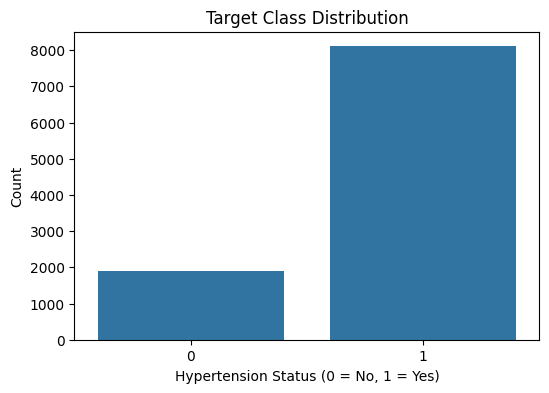

In [ ]:
# =========================
#  Class distribution
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(x="hypertension_status", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Hypertension Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


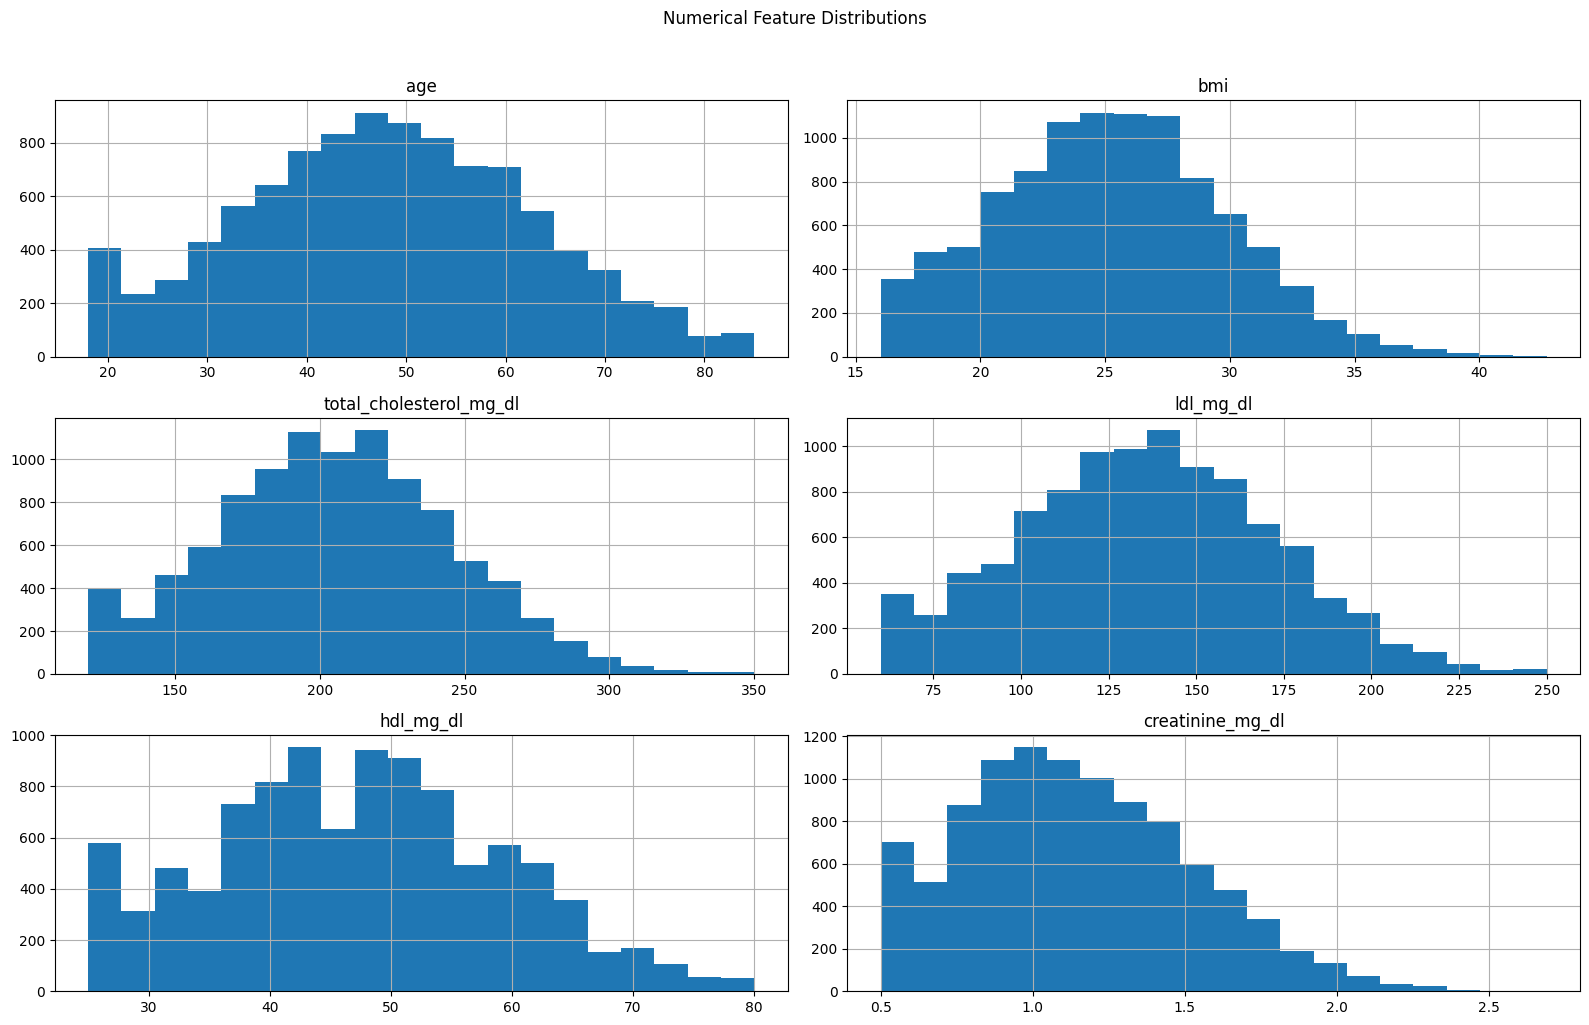

In [ ]:
# =========================
#  Histograms for numerical features
# =========================
df[numerical_cols].hist(figsize=(16, 10), bins=20)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


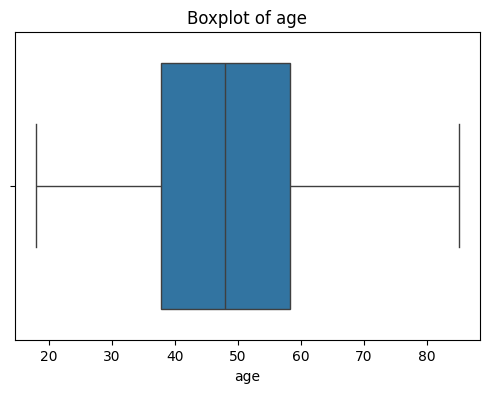

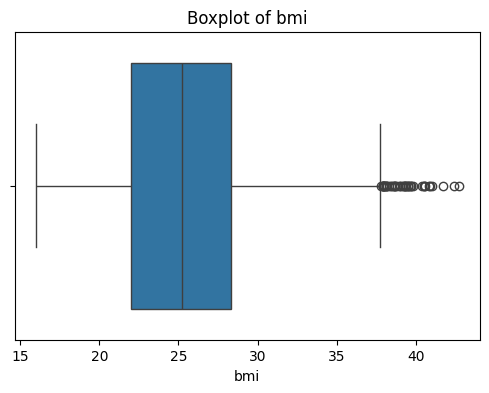

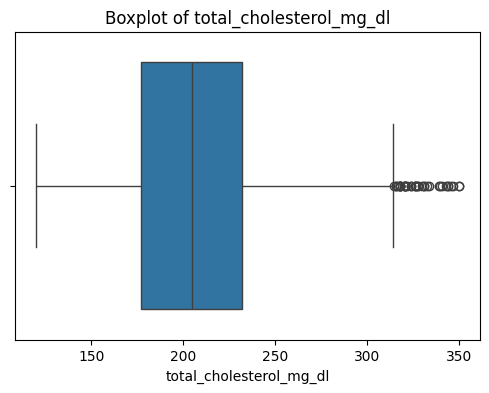

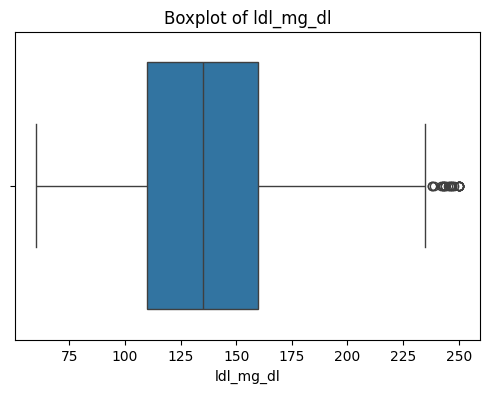

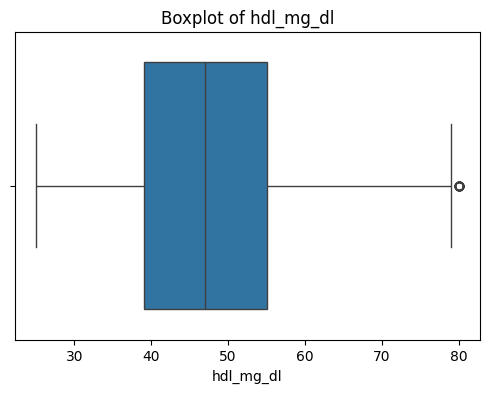

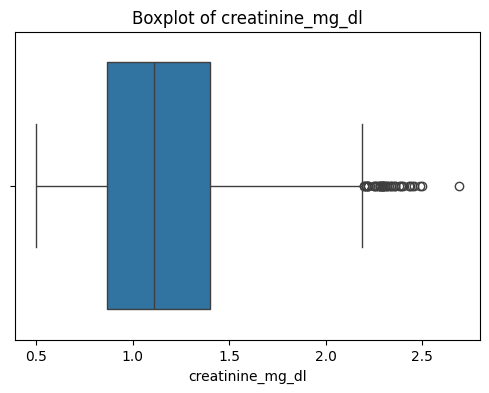

In [ ]:
# =========================
#  Boxplots for outlier inspection
# =========================
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


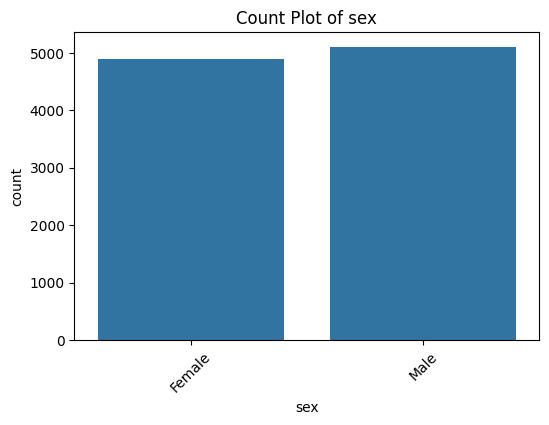

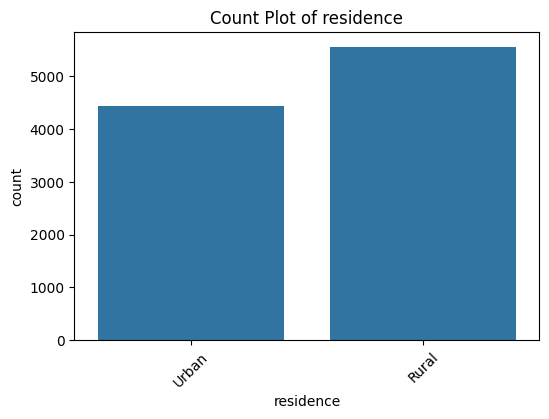

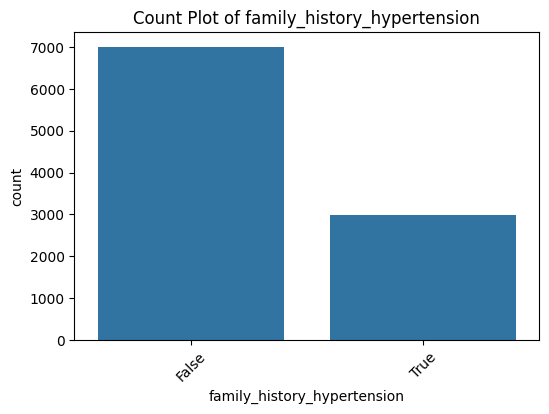

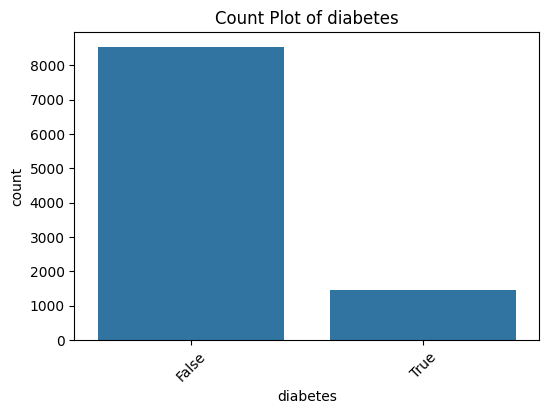

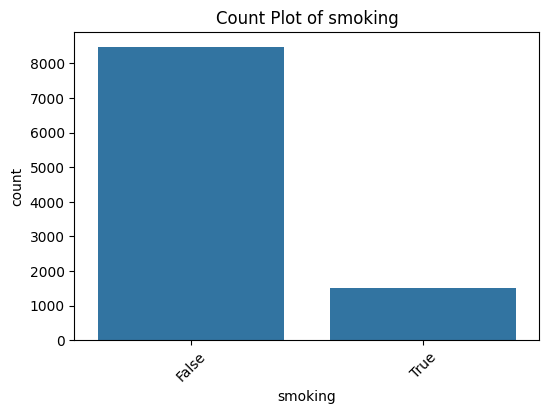

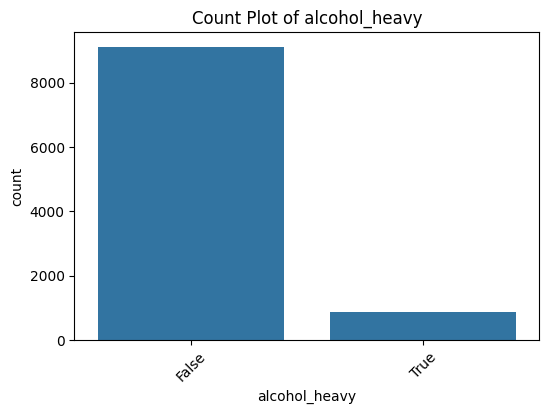

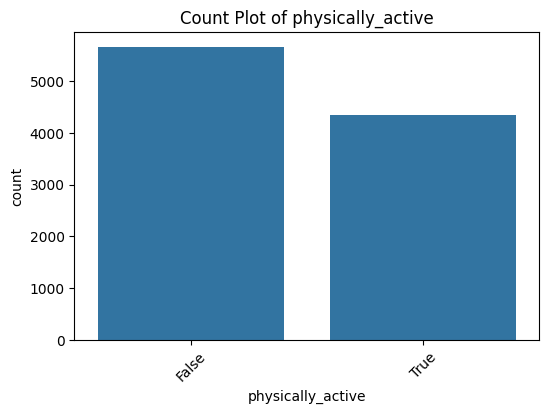

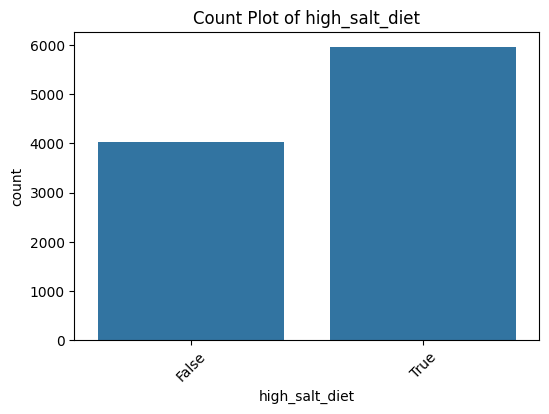

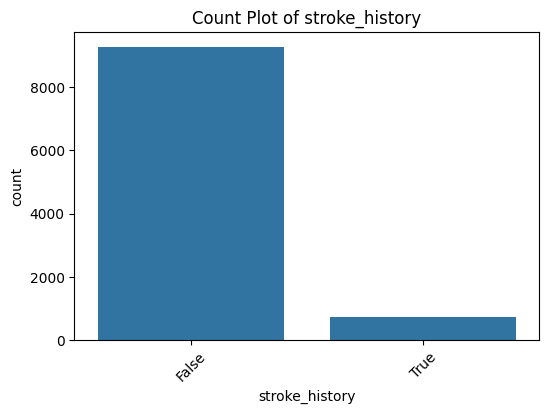

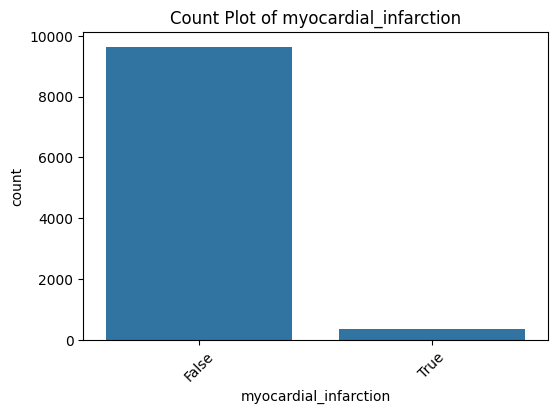

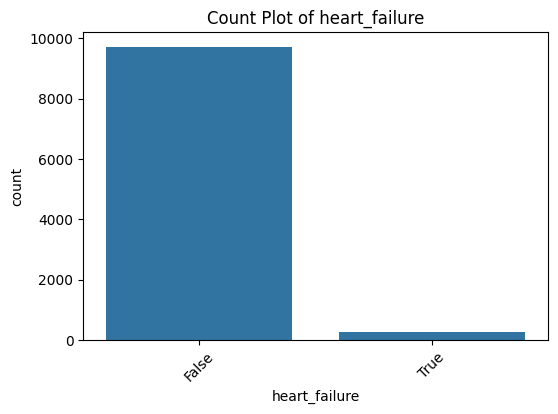

In [ ]:
# =========================
#  Countplots for categorical/boolean features
# =========================
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()


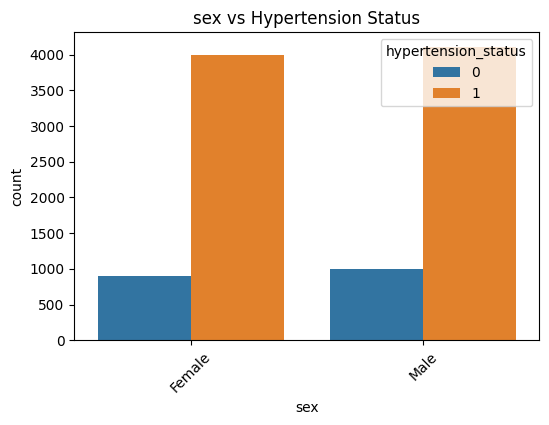

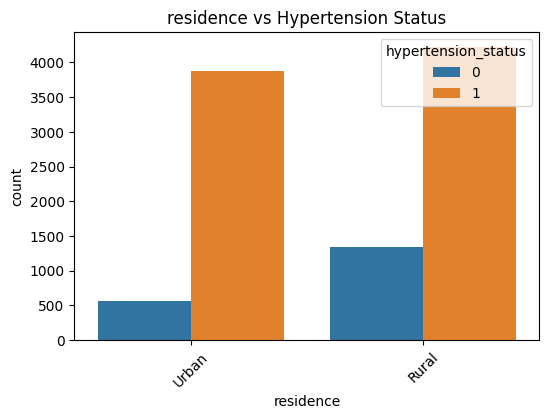

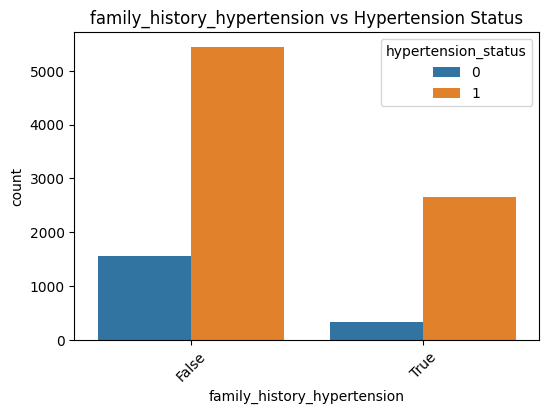

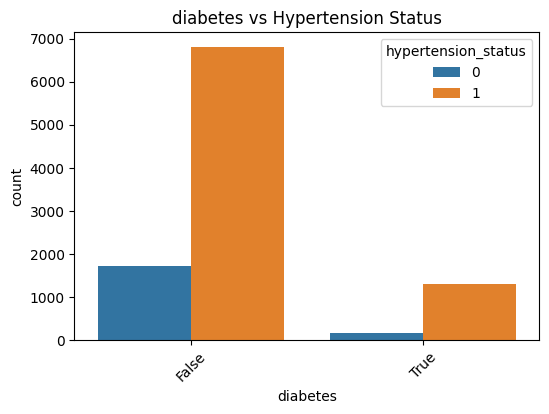

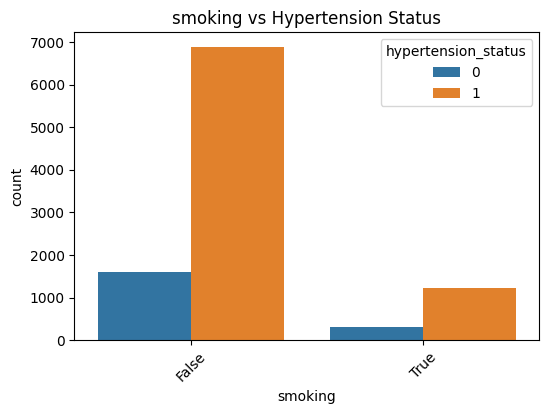

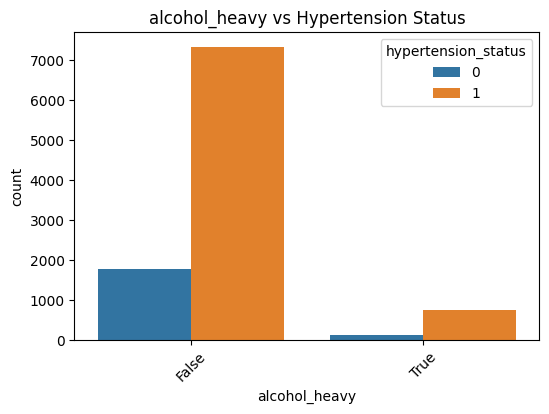

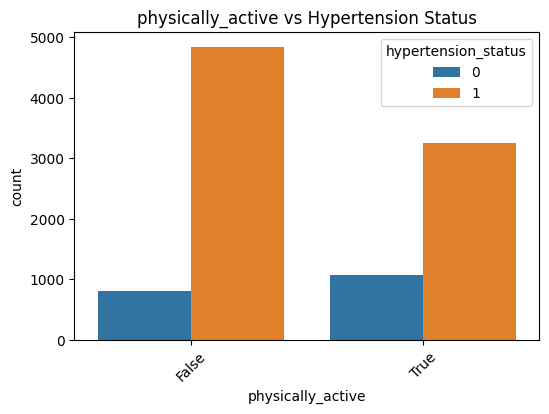

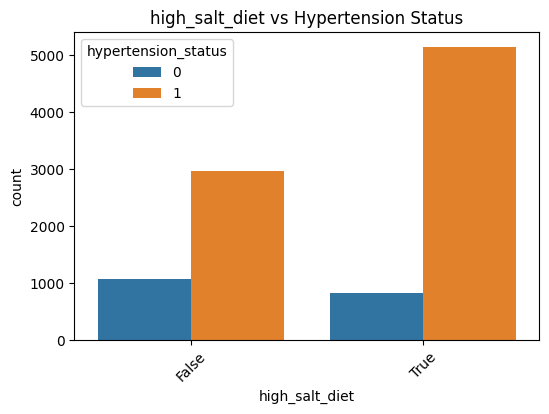

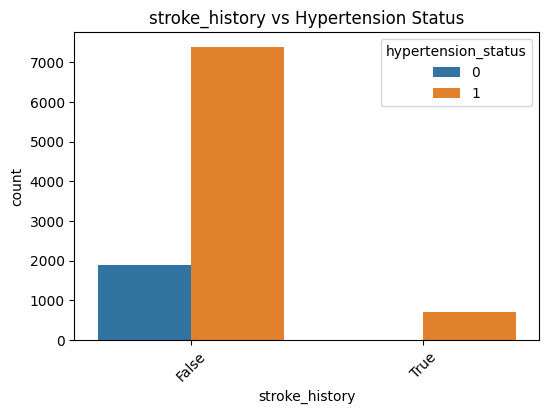

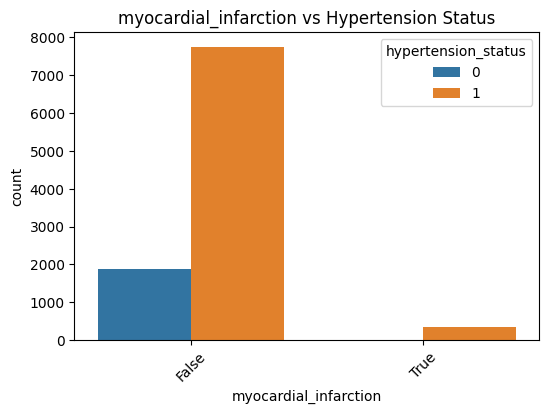

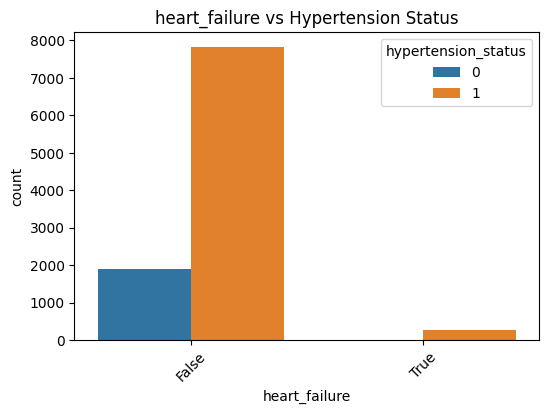

In [ ]:
# =========================
# Feature vs target analysis (categorical/boolean)
# =========================
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue="hypertension_status", data=df)
    plt.title(f"{col} vs Hypertension Status")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# To show Percentace
#===============================

for col in categorical_cols:
    print(f"\n===== {col} vs Hypertension =====")

    table = pd.crosstab(
        df[col],
        df["hypertension_status"],
        normalize="index"
    )

    print(table)


===== sex vs Hypertension =====
hypertension_status  Hypertensive    Normal
sex                                        
Female                   0.817123  0.182877
Male                     0.804152  0.195848

===== residence vs Hypertension =====
hypertension_status  Hypertensive    Normal
residence                                  
Rural                    0.760072  0.239928
Urban                    0.873649  0.126351

===== family_history_hypertension vs Hypertension =====
hypertension_status          Hypertensive    Normal
family_history_hypertension                        
False                            0.777619  0.222381
True                             0.887442  0.112558

===== diabetes vs Hypertension =====
hypertension_status  Hypertensive    Normal
diabetes                                   
False                    0.797798  0.202202
True                     0.884563  0.115437

===== smoking vs Hypertension =====
hypertension_status  Hypertensive    Normal
smoking         

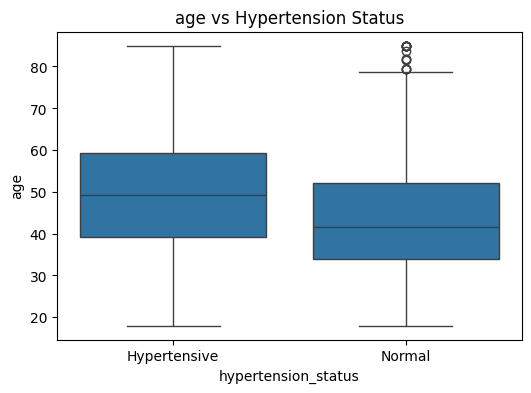

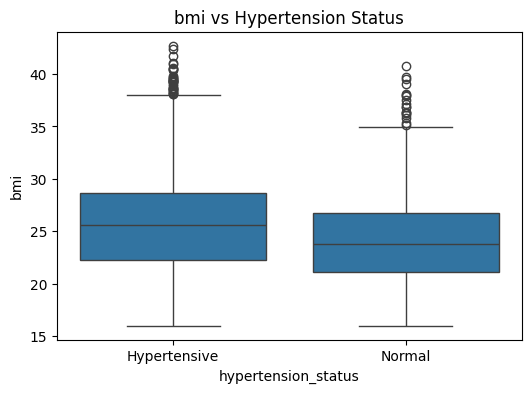

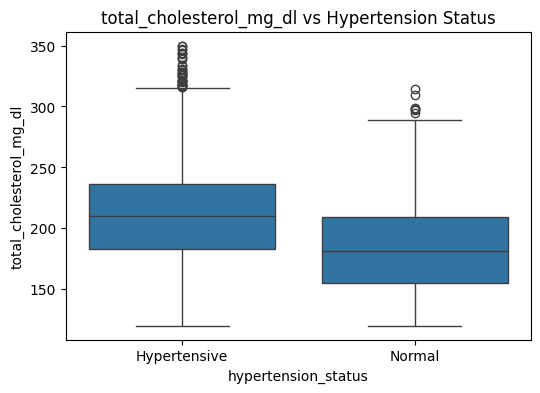

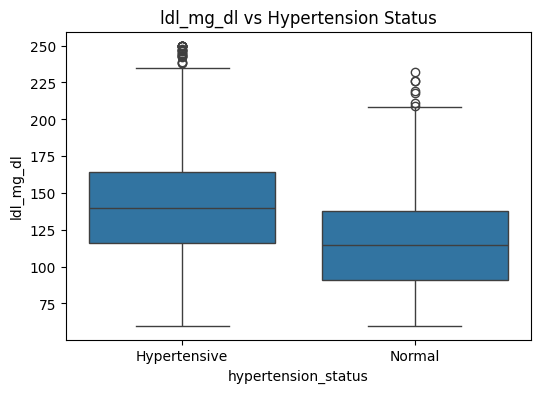

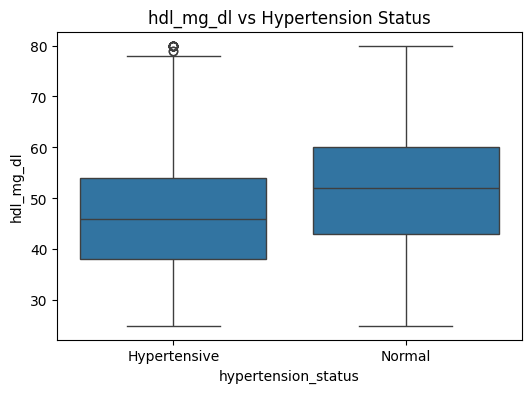

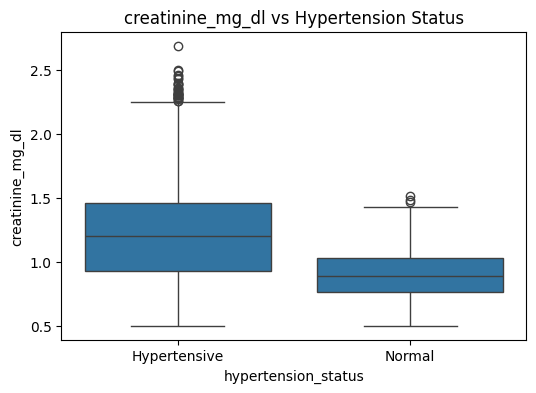

In [ ]:
# =========================
# Numerical features vs target
# =========================
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="hypertension_status", y=col, data=df)
    plt.title(f"{col} vs Hypertension Status")
    plt.show()

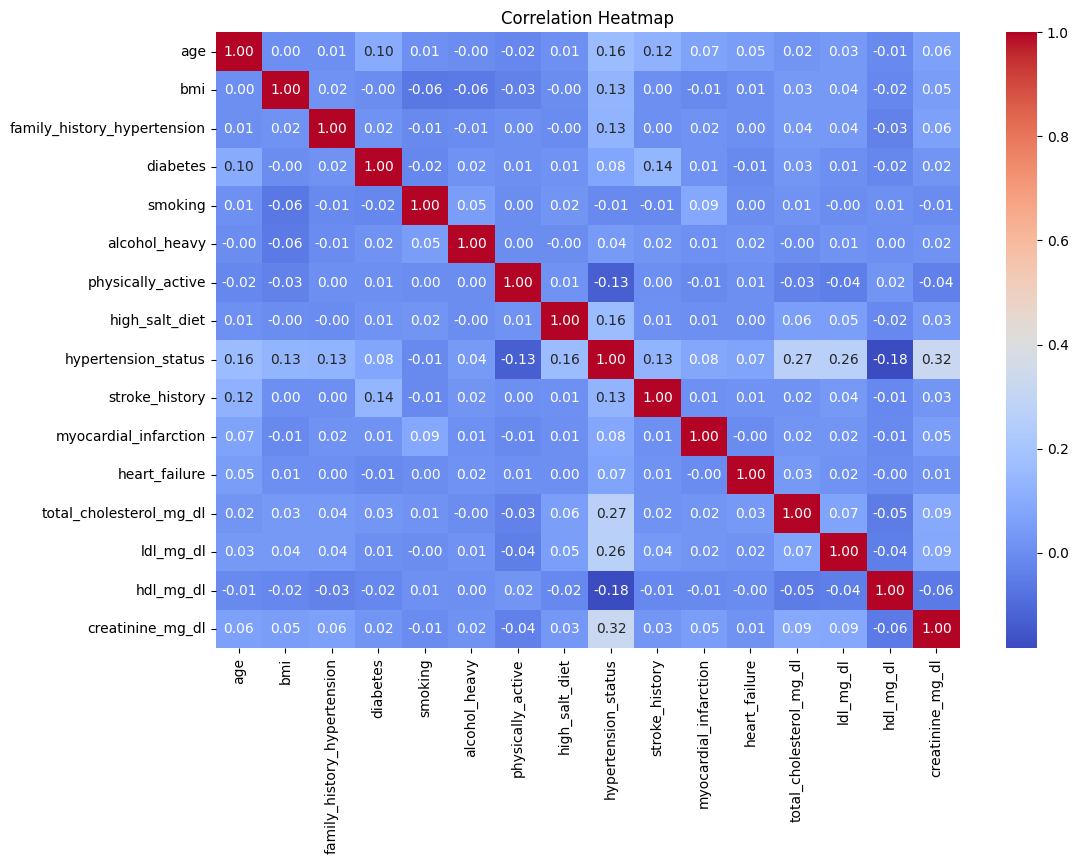

In [ ]:
# =========================
# Correlation heatmap
# =========================
# Convert boolean columns to integers temporarily for correlation
df_corr = df.copy()
bool_cols = df_corr.select_dtypes(include=["bool"]).columns

for col in bool_cols:
    df_corr[col] = df_corr[col].astype(int)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
#relation Ranking of features to Target
corr_with_target = df_corr.corr(numeric_only=True)["hypertension_status"].sort_values(ascending=False)

print(corr_with_target)

hypertension_status            1.000000
creatinine_mg_dl               0.320969
total_cholesterol_mg_dl        0.268937
ldl_mg_dl                      0.264582
high_salt_diet                 0.159138
age                            0.159065
bmi                            0.134756
family_history_hypertension    0.128343
stroke_history                 0.126226
myocardial_infarction          0.081114
diabetes                       0.078264
heart_failure                  0.074335
alcohol_heavy                  0.039417
smoking                       -0.009485
physically_active             -0.132091
hdl_mg_dl                     -0.183727
Name: hypertension_status, dtype: float64


## End Section

# Data Preprocessing

IQR Method:

This is the standard academic method.

Concept:


In [ ]:
def detect_outliers_iqr(df, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_summary[col] = len(outliers)

    return outlier_summary

outliers_count = detect_outliers_iqr(df, numerical_cols)
print(outliers_count)

{'age': 0, 'bmi': 45, 'total_cholesterol_mg_dl': 38, 'ldl_mg_dl': 23, 'hdl_mg_dl': 34, 'creatinine_mg_dl': 44}
